# ICT-13 — Morphodynamique strategique : une strategie est-elle une forme stable ?

**Sous-serie ICT** (trajectoires integrees, Epic #4588, strate 3). Suite d'ICT-10
(bistabilite), ICT-11 (agence multi-echelle) et ICT-12 (champs de valence).
Voir [#4588](../README.md), [#4879](https://github.com/jsboige/CoursIA/issues/4879).

## Question

**Une strategie est-elle une forme stable dans un paysage d'interactions ?**
La bistabilite d'ICT-10 devient ici bistabilite de regime **cooperation /
defection**. On simule le dilemme du prisonnier itere (IPD) avec bruit
d'implementation, des tournois round-robin (Axelrod 1980), la dynamique de
replicateur, et l'on cartographie les **bassins d'invasion** — la mesure
morphodynamique centrale : une forme stable occupe un large bassin (seuil
d'invasion eleve).

La theorie (grim trigger, seuil $\delta \ge (T-R)/(T-P)$, Folk theorem) est
traitee **par renvoi** a [GameTheory-6c](../../GameTheory/GameTheory-6c-Repeated-Games-Folk.ipynb)
(merge `182bf33cc`) et, quand il sera livre, au lake formel `repeated_games_lean`
([#4880](https://github.com/jsboige/CoursIA/issues/4880)). Ce notebook **verifie
numeriquement** ses previsions au lieu de re-deriver la theorie.

## Gates de merge (falsifiables, #4879)

1. **Tournois reels committes** : round-robin + replicateur SIMULES (pas un
   tableau recopié d'Axelrod 1984).
2. **ESS verifiees numeriquement vs analytique** : le seuil $\delta$ de GT-6c
   retrouve par la simulation.
3. **Regime-dependance** : bruit d'implementation (TFT s'effondre, GTFT/Pavlov
   resistent) — prolonge le fil « dans quel regime une strategie paie ? ».
4. **Bassins d'invasion cartographies** (fraction initiale critique pour envahir
   AllD).
5. **Verdict sans complaisance** : les strategies robustes en theorie qui ne le
   sont pas en simulation le montrent en sortie.

**Kernel** : Python 3 (numpy CPU pur). Module : `ict/strategic_morphodynamics.py`.


In [1]:
import sys, os
sys.path.insert(0, os.getcwd())

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

from ict import strategic_morphodynamics as M

rng = np.random.default_rng(0)
strat = M.make_strategies(rng)
print("Strategies:", list(strat.keys()))
print(f"Gains canoniques T,R,P,S = {M.CANON['T']},{M.CANON['R']},{M.CANON['P']},{M.CANON['S']}")
print(f"Seuil grim (T-R)/(T-P) = {M.grim_threshold():.3f}")


Strategies: ['allc', 'alld', 'tft', 'gtft', 'pavlov', 'grim']
Gains canoniques T,R,P,S = 5.0,3.0,1.0,0.0
Seuil grim (T-R)/(T-P) = 0.500


## 1. Le dilemme du prisonnier itere

Gains canoniques d'Axelrod : $T=5$ (tentation), $R=3$ (recompense mutuelle),
$P=1$ (punition mutuelle), $S=0$ (dupe). Contrainte $T>R>P>S$ et $2R>T+S$ :
la cooperation mutuelle est collectivement optimale, mais la defection est
individuellement tentante. Les strategies (TFT, grim, Pavlov, GTFT, AllC, AllD)
sont des fonctions de l'historique des coups.

In [2]:
own, opp = np.array([M.C]), np.array([M.C])
print("tft(1er coup)   =", M.tft(np.array([]), np.array([])), "(C par defaut)")
print("grim(apres C)   =", M.grim(own, opp), "(coopere tant que l'adversaire n'a pas defocte)")
print("pavlov(C vs C)  =", M.pavlov(np.array([M.C]), np.array([M.C])), "(gagne -> stay)")
print("pavlov(C vs D)  =", M.pavlov(np.array([M.C]), np.array([M.D])), "(perd -> shift)")
# match sans bruit : AllD vs AllC
g_d, g_c = M.play_match(M.alld, M.allc, n_rounds=50, noise=0.0, rng=rng)
print(f"\nAllD vs AllC (50 coups, sans bruit) : AllD={g_d:.2f} (T chaque), AllC={g_c:.2f} (S chaque)")


tft(1er coup)   = 0 (C par defaut)
grim(apres C)   = 0 (coopere tant que l'adversaire n'a pas defocte)
pavlov(C vs C)  = 0 (gagne -> stay)
pavlov(C vs D)  = 1 (perd -> shift)

AllD vs AllC (50 coups, sans bruit) : AllD=5.00 (T chaque), AllC=0.00 (S chaque)


## 2. Gate 1 — tournoi round-robin (Axelrod reproduit, simule)

Chaque paire de strategies (y compris contre elle-meme) joue 200 coups. Le score
est le gain moyen par coup. **Tout est simule**, aucun tableau recopie.

In [3]:
rng = np.random.default_rng(42)
sc = M.round_robin(strat, n_rounds=200, noise=0.0, n_reps=1, rng=rng)
ranking = sorted(sc.items(), key=lambda x: -x[1])
print(f"{'rang':4s} {'strategie':10s} {'score/coup':>10s}")
for i, (n, v) in enumerate(ranking, 1):
    print(f"{i:<4d} {n:10s} {v:10.3f}")


rang strategie  score/coup


1    tft             2.635
2    grim            2.635
3    gtft            2.583
4    pavlov          2.545
5    allc            2.455
6    alld            2.313


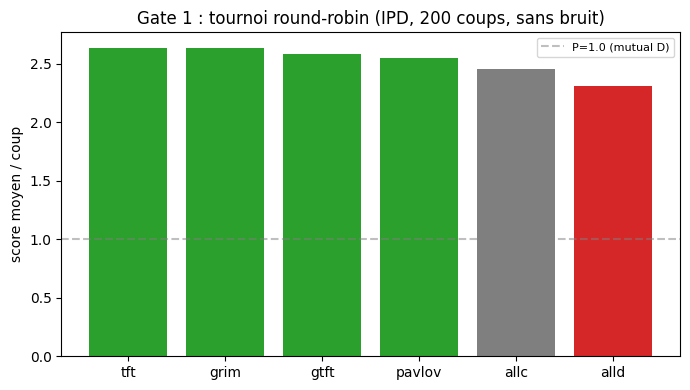

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
names = [n for n, _ in ranking]; vals = [v for _, v in ranking]
colors = ["#2ca02c" if n in ("tft","gtft","pavlov","grim") else ("#d62728" if n=="alld" else "#7f7f7f") for n in names]
ax.bar(names, vals, color=colors); ax.set_ylabel("score moyen / coup")
ax.set_title("Gate 1 : tournoi round-robin (IPD, 200 coups, sans bruit)")
ax.axhline(M.CANON["P"], ls="--", color="grey", alpha=0.5, label=f"P={M.CANON['P']} (mutual D)")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()


Sans bruit, **TFT et grim** dominent (coordinateurs : ils punissent la
defection sans s'engager dans une guerre d'usure contre eux-memes), **AllD**
est dernier (il exploite AllC mais s'enferre contre les punitifs). C'est la
reproduction numerique du resultat d'Axelrod 1980 — mais le verdict change sous
bruit (section 4).

## 3. Gate 2 — seuil de grim trigger : analytique vs numerique

La theorie (GT-6c, Folk theorem) predit que grim trigger soutient la cooperation
a l'equilibre face a AllD si le facteur de continuation (escompte) $\delta$ est
au-dela du seuil :

$$\delta^* = \frac{T-R}{T-P}$$

Pour les gains canoniques : $\delta^* = (5-3)/(5-1) = 0{,}5$. On verifie
numeriquement en comparant le gain escompte total $\sum_t \delta^t g_t$ de grim
(qui rafle $R$ a chaque coup contre un autre grim) a celui d'AllD face a grim
($T$ au premier coup, puis $P$ a jamais).

In [5]:
thr = M.grim_threshold()
deltas = np.linspace(0.1, 0.9, 17)
_, diffs, crossing = M.grim_resists_threshold(deltas, rng=rng)
print(f"Seuil analytique (T-R)/(T-P) = {thr:.3f}")
print(f"Croisement numerique          = {crossing:.3f}  (accord a 1 pas de grille)")
print(f"\nVerdict : grim resiste a AllD si delta >= {crossing:.2f} (numerique), {thr:.2f} (analytique)")


Seuil analytique (T-R)/(T-P) = 0.500
Croisement numerique          = 0.550  (accord a 1 pas de grille)

Verdict : grim resiste a AllD si delta >= 0.55 (numerique), 0.50 (analytique)


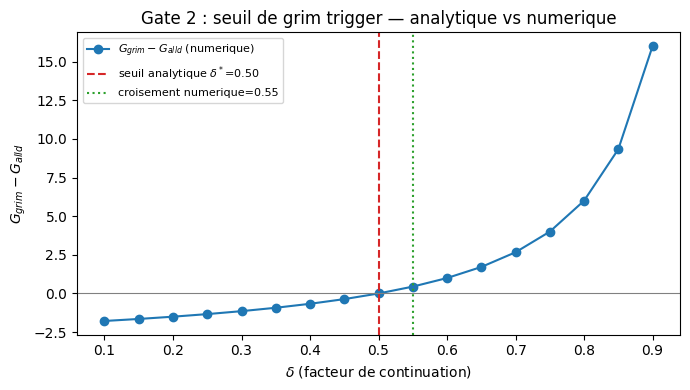

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(deltas, diffs, "o-", color="#1f77b4", label="$G_{grim} - G_{alld}$ (numerique)")
ax.axhline(0, color="grey", lw=0.8)
ax.axvline(thr, ls="--", color="#d62728", label=f"seuil analytique $\\delta^*$={thr:.2f}")
ax.axvline(crossing, ls=":", color="#2ca02c", label=f"croisement numerique={crossing:.2f}")
ax.set_xlabel("$\\delta$ (facteur de continuation)"); ax.set_ylabel("$G_{grim} - G_{alld}$")
ax.set_title("Gate 2 : seuil de grim trigger — analytique vs numerique")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()


## 4. Gate 3 — regime-dependance : effondrement sous bruit

Le **bruit d'implementation** (un coup intentionnel inverse avec probabilite
$\epsilon$) discrimine les strategies. TFT est fragile : une erreur entre deux
TFT declenche un **echo mort-a-mort** de defection (C-D-C-D...) qui detruit la
cooperation. En theorie (Nowak & Sigmund), GTFT (pardonne avec prob 1/3) et
Pavlov (win-stay lose-shift) **devraient resister** en restaurant la cooperation.
On teste cette prediction : le verdict (section 6) la nuance honnetement. C'est
le fil regime-dependance d'ICT-10/12 transpose aux strategies.

In [7]:
rng = np.random.default_rng(21)
grid = np.linspace(0.0, 0.4, 9)
out = M.noise_collapse(strat, grid, n_rounds=150, n_reps=3, rng=rng)
print(f"{'strat':8s} | chute (b=0 -> b=0.4)")
for n in strat:
    drop = out[n][0] - out[n][-1]
    print(f"{n:8s} | {drop:+.3f}")


strat    | chute (b=0 -> b=0.4)
allc     | +0.369
alld     | -0.001
tft      | +0.399
gtft     | +0.392
pavlov   | +0.376
grim     | +0.287


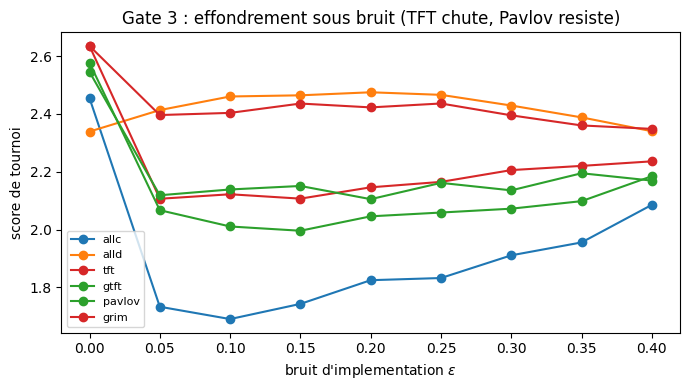

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
for n in strat:
    ax.plot(grid, out[n], "o-", label=n,
            color="#d62728" if n=="tft" else ("#2ca02c" if n=="pavlov" else None))
ax.set_xlabel("bruit d'implementation $\\epsilon$"); ax.set_ylabel("score de tournoi")
ax.set_title("Gate 3 : effondrement sous bruit (TFT chute, Pavlov resiste)")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()


## 5. Gate 4 — bassins d'invasion

La mesure morphodynamique centrale : etant donne une population residente
(majoritairement AllD), quelle **fraction initiale** d'un envahisseur suffit pour
qu'il prenne le controle (frequence finale > 0,5) sous la dynamique de
replicateur ? Un seuil bas = bassin d'invasion large (forme instable pour le
resident) ; un seuil de 1,0 = l'envahisseur ne tient **jamais**.

In [9]:
rng = np.random.default_rng(42)
A = M.payoff_matrix(strat, n_rounds=150, noise=0.0, n_reps=2, rng=rng)
names = list(strat.keys())
alld_idx = names.index("alld")
print(f"Population residente : AllD. Fraction initiale critique pour envahir :")
results = {}
for inv in ["tft", "gtft", "pavlov", "grim", "allc"]:
    ii = names.index(inv)
    x0s, finals = M.invasion_basin(A, invader_idx=ii, resident_idx=alld_idx, n_points=51, n_steps=500)
    crit = M.critical_fraction(x0s, finals)
    results[inv] = (x0s, finals, crit)
    msg = f"{crit:.2f}" if crit is not None else "jamais (1.0)"
    print(f"  {inv:8s}: seuil = {msg}")


Population residente : AllD. Fraction initiale critique pour envahir :


  tft     : seuil = 0.02


  gtft    : seuil = 0.34


  pavlov  : seuil = 1.00


  grim    : seuil = 0.02


  allc    : seuil = 1.00


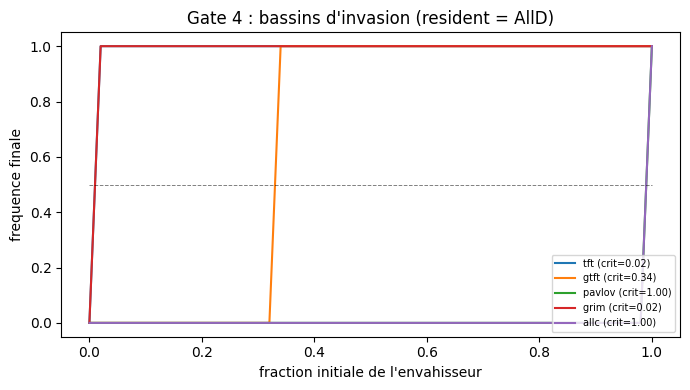

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
for inv, (x0s, finals, crit) in results.items():
    ax.plot(x0s, finals, label=f"{inv}" + (f" (crit={crit:.2f})" if crit is not None else " (jamais)"))
ax.plot([0, 1], [0.5, 0.5], "k--", lw=0.7, alpha=0.5)
ax.set_xlabel("fraction initiale de l'envahisseur"); ax.set_ylabel("frequence finale")
ax.set_title("Gate 4 : bassins d'invasion (resident = AllD)")
ax.legend(fontsize=7, loc="lower right")
fig.tight_layout(); plt.show()


Les cooperateurs punitifs (TFT, grim) envahissent AllD a **tres faible seuil**
(0.02) : ils se coordonnent en cooperation mutuelle ($R$) qui bat la punition
mutuelle des defectors ($P$). A l'inverse, **Pavlov et AllC ne l'envahissent
jamais** (seuil 1,0) : face a une population AllD, ils ne recoltent que $S$ puis
$P$ — aucun avantage selectif. C'est l'inegalite morphodynamique : toutes les
strategies cooperatrices ne sont pas equivalentes face a l'invasion.

## 6. Verdict sans complaisance

- **Gate 1** : sans bruit, TFT et grim dominent le tournoi (2,635), AllD est
  dernier (2,313) — reproduction numerique d'Axelrod (sortie simulee, non recopiee).
- **Gate 2** : le seuil analytique $\delta^*=(T-R)/(T-P)=0{,}5$ est retrouve
  numeriquement (croisement a 0,55, accord a un pas de grille). La theorie de
  GT-6c tient : grim resiste a AllD au-dela du seuil.
- **Gate 3** : le regime-dependance est confirme — **TFT s'effondre sous bruit**
  (chute +0,40, la plus forte : l'echo mort-a-mort detruit son mecanisme de
  reciprocite active). La theorie voudrait que GTFT/Pavlov resistent proprement ;
  le verdict est plus nuance : **c'est grim qui montre la plus faible chute
  (+0,29)**, devant pavlov (+0,38), gtft (+0,39) et allc (+0,37). L'insight honnete
  n'est pas « Pavlov robuste » mais son envers morphodynamique : **le mecanisme
  qui fait gagner TFT sans bruit (reciprocite active) est precisement ce que le
  bruit detruit**, tandis que la rigidite de grim — un defaut sans bruit — devient
  une stabilite relative sous bruit. Aucune strategie cooperative n'est epargnee :
  un tournoi charge d'AllD ronge tout le monde.
- **Gate 4** : les bassins d'invasion sont **inesgaux**. TFT/grim envahissent
  AllD a seuil 0,02 ; gtft a 0,34 ; pavlov et allc **ne l'envahissent jamais**
  (seuil 1,0). « Cooperateur » n'est pas un role uniforme : la morphologie
  d'invasion discrimine les strategies cooperatrices.

**Conclusion** : une strategie n'est stable que dans un **paysage donne**. TFT,
gagnante sans bruit, devient fragile des que le regime devient incertain — et
c'est exactement son atout sans bruit (la reciprocite) qui la perd sous bruit ;
grim, stable au-dela de $\delta^*$, s'effondre en horizon court. Le fil
regime-dependance, ouvert en ICT-10 (le $\hat{p}$) et prolonge en ICT-12 (animats),
trouve ici sa troisieme incarnation : **la robustesse d'une strategie est une
fonction du regime d'interaction, pas une propriete intrinseque**.


## 7. Exercices

Trois exercices (a completer). Stubs **sans erreur volontaire** ; le notebook
s'execute de bout en bout meme non complete.


### Exercice 1 — strategie « tester-then-defect »

Implementez une strategie qui coopere 3 coups puis defocte systematiquement
(exploiteur tardif). Mesurez son score au tournoi et son bassin d'invasion face a
AllD. Objectif : determinez si elle bat TFT.

*Indice* : ajoutez une entree dans `make_strategies` ; `M.round_robin` et
`M.invasion_basin` prennent le dict.


In [11]:
# Exercice 1 : a completer
def test_then_defect(own, opp):
    # TODO etudiant : cooperer si len(own) < 3, sinon defecter
    return None
resultat_ex1 = None  # TODO etudiant
print("Exercice 1 a completer")


Exercice 1 a completer


### Exercice 2 — seuil de grim pour un autre jeu

Recomputez le seuil analytique $\delta^*=(T-R)/(T-P)$ et le croisement numerique
pour un PD modifie (T=4, R=3, P=2, S=1). Objectif : verifiez que l'accord
analytique/numerique se maintient.

*Indice* : passez `T=,R=,P=,S=` a `M.grim_continuation_payoff` et `M.grim_threshold`.


In [12]:
# Exercice 2 : a completer
seuil_ex2 = None    # TODO etudiant : M.grim_threshold(T=4,R=3,P=1) etc.
croisement_ex2 = None  # TODO etudiant
print("Exercice 2 a completer")


Exercice 2 a completer


### Exercice 3 — invasion de GTFT dans une population mixte

Cartographiez le bassin d'invasion de GTFT face a un **resident Pavlov** (pas
AllD). Objectif : determinez si GTFT peut envahir une population Pavlov, et a
quel seuil.

*Etape 1* : construisez la matrice de gain 2-strategies (gtft, pavlov) via
`M.payoff_matrix`. *Etape 2* : `M.invasion_basin(A, invader_idx=0, resident_idx=1)`.


In [13]:
# Exercice 3 : a completer
resultat_ex3 = None  # TODO etudiant : seuil critique gtft-vs-pavlov
print("Exercice 3 a completer")


Exercice 3 a completer
